# CIEM5220 — Dynamics of Structures under Moving Loads, Part B
## Hyperloop on Periodic Supports — Problem 1


Computational logbook for Problem 1 (one analytical model + one ANSYS FE model).


In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.signal import find_peaks

plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11

## Parameters (assignment Appendix)

Note on the mass term: the appendix gives $\rho$ *as* the mass per unit length (1330 kg/m); the beam
inertia coefficient is $\rho_\text{mat}A$, which equals 1330 here since $A=1$. So I use 1330 directly.


In [2]:
EI    = 2.5e10        # Nm^2  bending stiffness (E with I=1)
rho   = 1330.0        # kg/m  mass per unit length (A=1)
ks    = 4.4e8         # N/m   support stiffness
cs    = 1e4           # Ns/m  support damping (time-domain only; a/b undamped)
d     = 16.0          # m     support spacing
L_tot = 160.0         # m     FE beam length
Ks_hat = ks / EI      # matrix coefficient
kBZ  = np.pi / d       # first Brillouin-zone boundary
kmax = 3 * kBZ         # three zones

## 1. Sub-question (a) — Analytical dispersion equation

Inside a cell the undamped, harmonic beam equation is $EI\,W''''-\rho\omega^2 W=0$ with
$W_0=A\sin\beta x+B\cos\beta x+C\sinh\beta x+D\cosh\beta x$, $\beta^4=\rho\omega^2/EI$. Floquet
periodicity $W_1(x)=\xi W_0(x-d)$, $\xi=e^{-ikd}$, plus continuity of displacement, slope and moment
and shear-equilibrium with the spring at the support, give a $4\times4$ system
$\mathbf M(\xi,\beta)(A,B,C,D)^\top=0$. $\det\mathbf M=0$ is a 4th-order polynomial in $\xi$; I build
it numerically and take its 4 roots. $|\xi|=1$ → propagating, $|\xi|\ne1$ → evanescent.



In [3]:
def system_matrix(b, xi, Ks_hat=Ks_hat):
    '''4x4 Floquet system matrix M(beta, xi). det M = 0 is the dispersion equation.'''
    sL, cL = np.sin(b * d),  np.cos(b * d)
    sH, cH = np.sinh(b * d), np.cosh(b * d)
    b2, b3 = b**2, b**3
    return np.array([
        [sL,                  cL - xi,              sH,                  cH - xi             ],
        [b*cL - b*xi,        -b*sL,                 b*cH - b*xi,         b*sH                ],
        [-b2*sL,             -b2*cL + b2*xi,        b2*sH,               b2*cH - b2*xi       ],
        [b3*cL - b3*xi + Ks_hat*sL,
         -b3*sL + Ks_hat*cL,
         -b3*cH + b3*xi + Ks_hat*sH,
         -b3*sH + Ks_hat*cH],
    ], dtype=complex)

def xi_roots(b, Ks_hat=Ks_hat):
    '''Return the 4 roots xi of det M = 0 by sampling the quartic (Vandermonde).'''
    s = 1.5 * np.exp(2j * np.pi * np.arange(5) / 5)
    dets = np.array([np.linalg.det(system_matrix(b, xj, Ks_hat)) for xj in s])
    V = np.vander(s, N=5, increasing=True)
    coeffs = np.linalg.solve(V, dets)
    return np.roots(coeffs[::-1])

# frequency sweep
omega = np.linspace(1.0, 1000.0, 4000)
beta  = (rho * omega**2 / EI) ** 0.25
prop_w, prop_k, evan_w, evan_k = [], [], [], []
TOL = 2e-3
for w, b in zip(omega, beta):
    for xi in xi_roots(b):
        mag = abs(xi)
        if mag < 1e-12:
            continue
        Re_k = -np.angle(xi) / d
        if abs(mag - 1.0) < TOL:
            prop_w.append(w); prop_k.append(Re_k)
        else:
            evan_w.append(w); evan_k.append(Re_k)
prop_w, prop_k = np.array(prop_w), np.array(prop_k)
evan_w, evan_k = np.array(evan_w), np.array(evan_k)

# repeated-zone scheme over 3 Brillouin zones
def repeat_zones(kk, ww):
    K, W = [], []
    for n in (-2, -1, 0, 1, 2):
        ks_ = kk + n * 2 * kBZ
        m = np.abs(ks_) <= kmax + 1e-9
        K.append(ks_[m]); W.append(ww[m])
    return np.concatenate(K), np.concatenate(W)

pk, pw = repeat_zones(prop_k, prop_w)
ek, ew = repeat_zones(evan_k, evan_w)

# critical velocity = min phase velocity on the lowest branch (1st BZ)
low = (prop_w < 200.0) & (prop_k > 1e-3) & (prop_k <= kBZ + 1e-9)
kk, ww = prop_k[low], prop_w[low]
icr = np.argmin(ww / kk)
v_cr, k_cr, w_cr = (ww/kk)[icr], kk[icr], ww[icr]
print(f'Analytical V_cr = {v_cr:.0f} m/s  (tangent at k={k_cr:.3f} rad/m, w={w_cr:.0f} rad/s)')

Analytical V_cr = 858 m/s  (tangent at k=0.195 rad/m, w=167 rad/s)


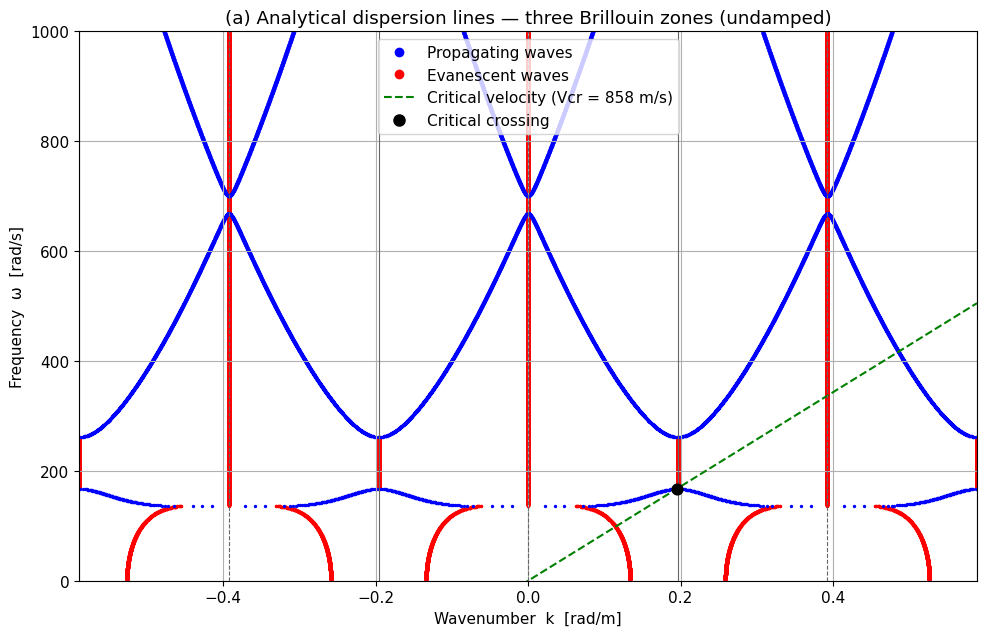

In [11]:
# Analytical dispersion plot (dispersion_analytical.py)
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(ek, ew, s=2, color='red',  label='Evanescent waves')
ax.scatter(pk, pw, s=2, color='blue', label='Propagating waves')
k_line = np.array([-kmax, kmax])
ax.plot(k_line, v_cr * k_line, 'g--', lw=1.5)
ax.scatter([k_cr], [w_cr], s=60, color='black', zorder=5)
for n in range(-3, 4):
    ax.axvline(n * kBZ, color='0.4', lw=0.8, ls='-' if n % 2 else '--')
ax.set_xlim(-kmax, kmax); ax.set_ylim(0, 1000)
ax.set_xlabel('Wavenumber  k  [rad/m]'); ax.set_ylabel('Frequency  ω  [rad/s]')
ax.set_title('(a) Analytical dispersion lines — three Brillouin zones (undamped)')
handles = [
    Line2D([0],[0], marker='o', ls='', mfc='blue',  mec='blue',  ms=6, label='Propagating waves'),
    Line2D([0],[0], marker='o', ls='', mfc='red',   mec='red',   ms=6, label='Evanescent waves'),
    Line2D([0],[0], color='green', ls='--', lw=1.5, label=f'Critical velocity (Vcr = {v_cr:.0f} m/s)'),
    Line2D([0],[0], marker='o', ls='', mfc='black', mec='black', ms=8, label='Critical crossing'),
]
ax.legend(handles=handles, loc='upper center')
plt.tight_layout(); plt.show()

## 2. Sub-question (b) — Numerical dispersion (ANSYS modal analysis)

FE model: 160 `BEAM3` elements ($l_e=1$ m, 161 nodes), 11 `COMBIN14` springs every 16 m, simply
supported ends, undamped ($c_s=0$). Mode $n$ of a simply-supported beam has $n$ half-waves, so
$k_n=n\pi/L$ and $\omega_n=2\pi f_n$; the first zone edge $k=\pi/d$ is reached at $n=L/d=10$.


73 modes (13.55 .. 398.2 Hz); mode 1 = 13.55 Hz is a finite-domain artefact
Numerical V_cr = 818 m/s   (analytical 858 m/s, diff 4.7 %)


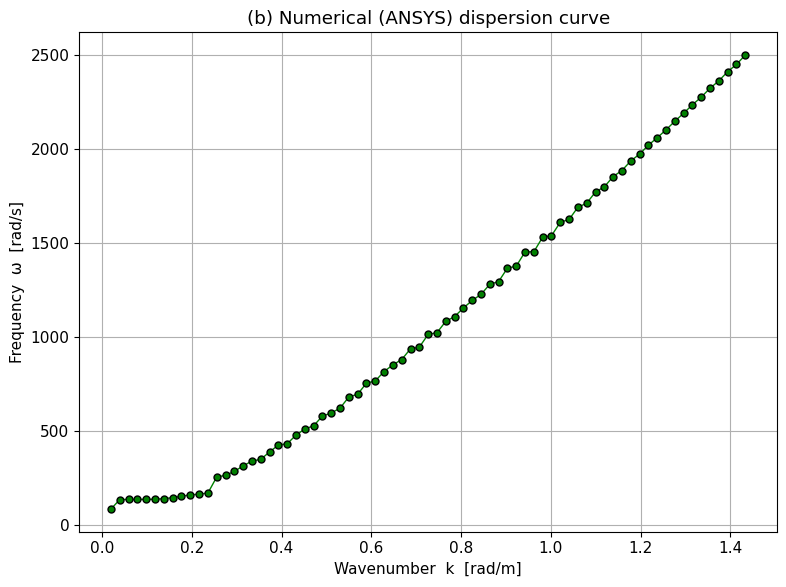

In [12]:
# numerical dispersion from the ANSYS modal frequencies
f = np.loadtxt('ansys_frequencies.txt')          # Hz (comment lines skipped)
n = np.arange(1, len(f)+1)
w_num  = 2*np.pi*f                               # rad/s
k_true = n*np.pi/L_tot                           # extended-zone wavenumber

def fold(k):                                     # into reduced zone [0, pi/d]
    kr = np.mod(k, 2*kBZ)
    return np.where(kr > kBZ, 2*kBZ - kr, kr)

# numerical critical velocity (first-BZ basis, incl. band-edge mode 10)
k_red = fold(k_true)
band1 = (w_num > 120) & (w_num < 180) & (k_red > 1e-2)
icr   = np.argmin(w_num[band1]/k_red[band1])
v_cr_num = (w_num[band1]/k_red[band1])[icr]
print(f'{len(f)} modes ({f[0]:.2f} .. {f[-1]:.1f} Hz); mode 1 = {f[0]:.2f} Hz is a finite-domain artefact')
print(f'Numerical V_cr = {v_cr_num:.0f} m/s   (analytical {v_cr:.0f} m/s, diff {abs(v_cr-v_cr_num)/v_cr*100:.1f} %)')

# Fig.5-style: numerical curve only
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(k_true, w_num, '-o', color='green', mec='k', ms=5, lw=1)
ax.set_xlabel('Wavenumber  k  [rad/m]'); ax.set_ylabel('Frequency  ω  [rad/s]')
ax.set_title('(b) Numerical (ANSYS) dispersion curve')
plt.tight_layout(); plt.show()

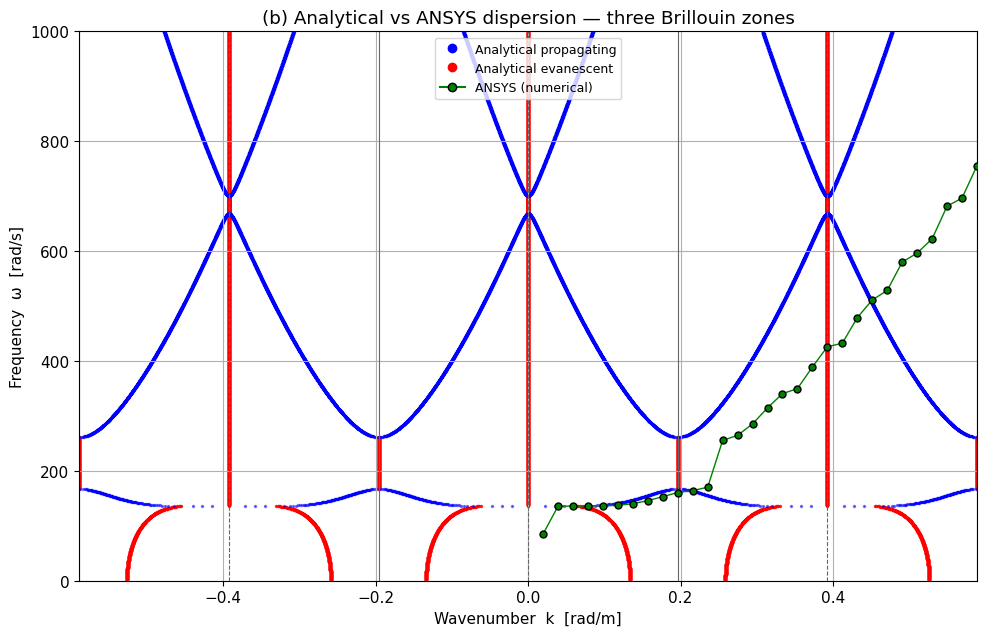

In [13]:
# analytical vs numerical dispersion (three zones)
sel = w_num <= 1000.0
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(ek, ew, s=2, color='red',  alpha=0.5)
ax.scatter(pk, pw, s=2, color='blue', alpha=0.5)
ax.plot(k_true[sel], w_num[sel], '-o', color='green', mec='k', ms=5, lw=1, zorder=4)
for m in range(-3, 4):
    ax.axvline(m*kBZ, color='0.4', lw=0.8, ls='-' if m % 2 else '--')
ax.set_xlim(-kmax, kmax); ax.set_ylim(0, 1000)
ax.set_xlabel('Wavenumber  k  [rad/m]'); ax.set_ylabel('Frequency  ω  [rad/s]')
ax.set_title('(b) Analytical vs ANSYS dispersion — three Brillouin zones')
handles = [
    Line2D([0],[0], marker='o', ls='', mfc='blue', mec='blue', ms=6, label='Analytical propagating'),
    Line2D([0],[0], marker='o', ls='', mfc='red',  mec='red',  ms=6, label='Analytical evanescent'),
    Line2D([0],[0], marker='o', color='green', mec='k', ms=6, label='ANSYS (numerical)'),
]
ax.legend(handles=handles, loc='upper center', fontsize=9)
plt.tight_layout(); plt.show()

### 2.1 Sanity check
Good agreement in the first band (low $\omega$); high-frequency divergence because the wavelength
approaches the 1 m mesh size. **Fake mode 1** (13.5 Hz) sits below the band;
re-running with near-zero $k_s$ (results provided in markdown) recovers the half-sine fundamental shape (sanity check that the model
is correct).


## 3. Sub-question (c) — Critical velocity + time-domain verification

$V_\text{cr}=\min_k(\omega/k)$ on the lowest branch. Below it the load gives a local dip; at it,
resonance; above it, two trailing waves.



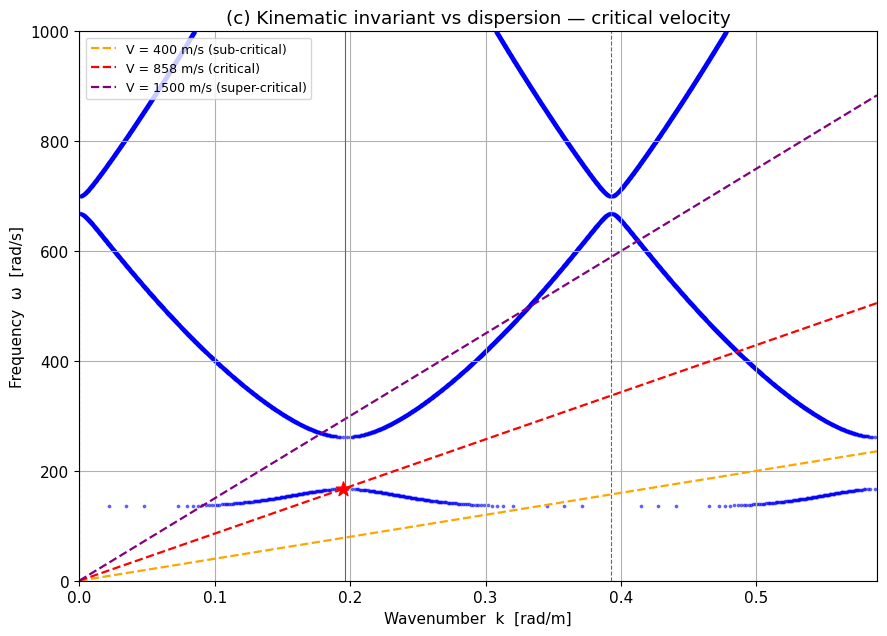

In [14]:
# kinematic-invariant lines over the analytical dispersion
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(pk, pw, s=3, c='blue', alpha=0.5)
kx = np.array([0, kmax])
for V, col, name in [(400,'orange','sub-critical'),
                     (round(v_cr),'red','critical'),
                     (1500,'purple','super-critical')]:
    ax.plot(kx, V*kx, '--', color=col, lw=1.6, label=f'V = {V} m/s ({name})')
ax.scatter([k_cr], [w_cr], s=120, marker='*', color='red', zorder=6)
for nn in range(0, 4):
    ax.axvline(nn*kBZ, color='0.4', lw=0.8, ls='-' if nn % 2 else '--')
ax.set_xlim(0, kmax); ax.set_ylim(0, 1000)
ax.set_xlabel('Wavenumber  k  [rad/m]'); ax.set_ylabel('Frequency  ω  [rad/s]')
ax.set_title('(c) Kinematic invariant vs dispersion — critical velocity')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

V = 400 m/s (sub-critical)      : peak |UY|=0.136 mm,  dominant w=[20, 129] rad/s
V = 835 m/s (~critical)         : peak |UY|=0.185 mm,  dominant w=[142] rad/s
V = 1500 m/s (super-critical)   : peak |UY|=0.123 mm,  dominant w=[134] rad/s


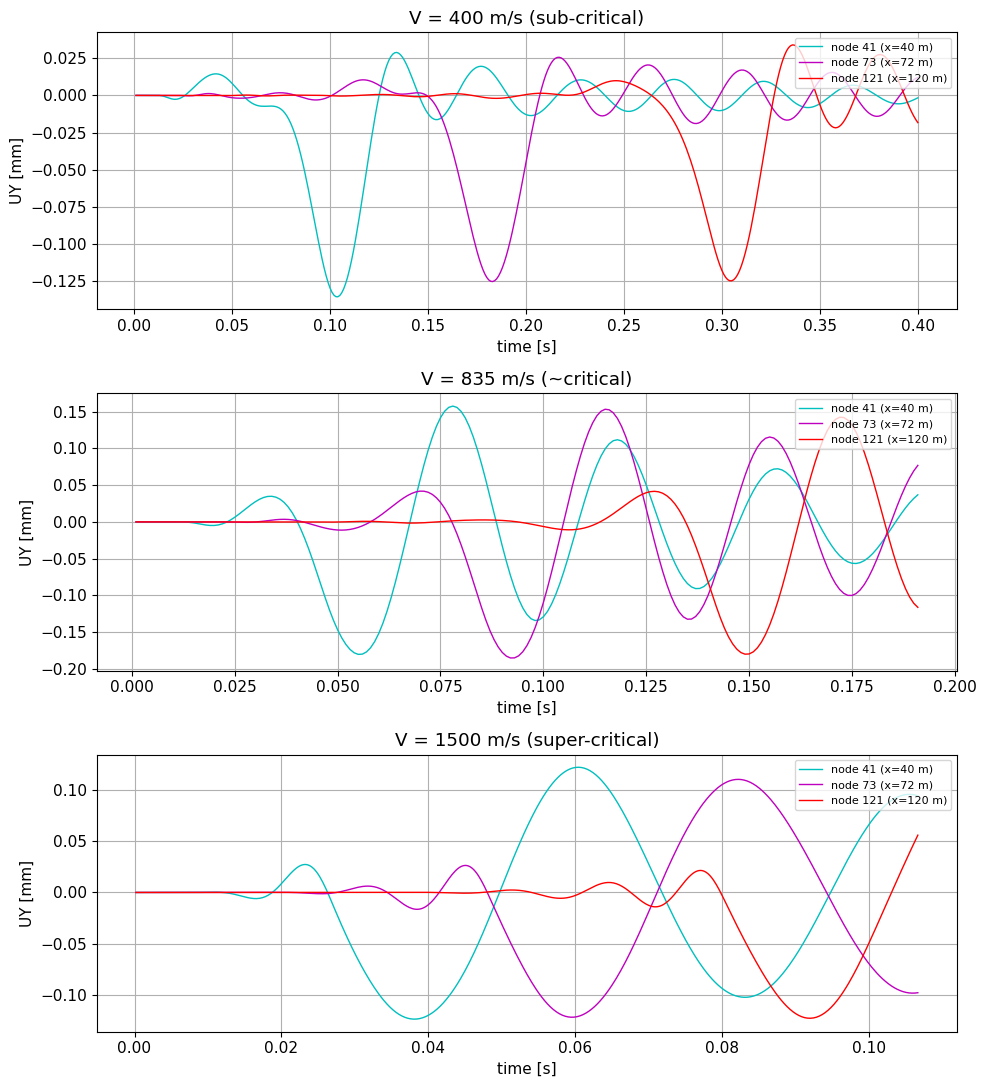

In [16]:
# Time histories from ANSYS POST26 output (four columns: time, node41, node73, node121)
NUM = re.compile(r'[-+]?(?:\d+\.\d*|\.\d+|\d+)(?:E[-+]?\d+)?')
def load_post26(fname):
    rows = [[float(x) for x in NUM.findall(line)]
            for line in open(fname) if len(NUM.findall(line)) == 4]
    a = np.array(rows)
    return a[:,0], {41: a[:,1], 73: a[:,2], 121: a[:,3]}

runs = {'V = 400 m/s (sub-critical)':   ('uy_V400.txt',  400),
        'V = 835 m/s (~critical)':      ('uy_V835.txt',  835),
        'V = 1500 m/s (super-critical)':('uy_V1500.txt', 1500)}
colors = {41:'c', 73:'m', 121:'r'}

fig, axes = plt.subplots(3, 1, figsize=(10, 11))
for ax, (title, (fname, V)) in zip(axes, runs.items()):
    t, sig = load_post26(fname)
    for nd, s in sig.items():
        ax.plot(t, s*1e3, color=colors[nd], lw=1.0, label=f'node {nd} (x={nd-1} m)')
    ax.set_title(title); ax.set_xlabel('time [s]'); ax.set_ylabel('UY [mm]')
    ax.legend(fontsize=8, loc='upper right')
    nd = max(sig, key=lambda k: np.max(np.abs(sig[k]))); s = sig[nd]
    dt = np.mean(np.diff(t))
    sw = (s - np.mean(s)) * np.hanning(len(s))
    F  = np.abs(np.fft.rfft(sw, 8192)); wax = 2*np.pi*np.fft.rfftfreq(8192, dt)
    b = wax <= 1000; F, wax = F[b], wax[b]
    pkk,_ = find_peaks(F, prominence=0.15*F.max()); pkk = pkk[np.argsort(F[pkk])[::-1]][:2]
    print(f'{title:32s}: peak |UY|={np.max(np.abs(s))*1e3:.3f} mm,  dominant w={sorted(round(wax[p]) for p in pkk)} rad/s')
plt.tight_layout(); plt.show()

### 3.1 Findings
Peak deflection 0.136 → **0.185** → 0.123 mm: the maximum at $\approx V_\text{cr}$ is the resonance. The critical-run ring frequency (~145–160 rad/s) matches the dispersion tangent (167 rad/s). Regimes: localised dip (sub) → building wave (critical) → trailing waves (super).


## 4. Sub-question (d) — Effect of support stiffness $k_s$

I evaluate $V_\text{cr}(k_s)$ via the lowest band-edge frequency at $k=\pi/d$ (the condition
$\xi=-1$), using the same verified `system_matrix`.


Pinned-span bending mode w_span = 167.1 rad/s -> V_cr ceiling = 851 m/s
  k_s x 1.00 -> V_cr =    851 m/s
  k_s x 1.50 -> V_cr =    851 m/s
  k_s x 2.00 -> V_cr =    851 m/s
  k_s x 3.00 -> V_cr =    851 m/s


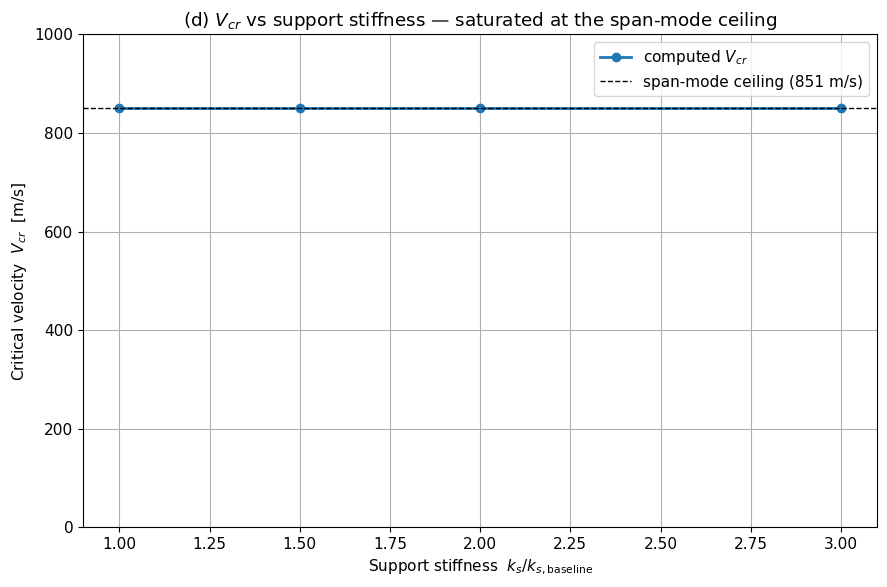

In [17]:
def w_band_edge(ks_value):
    '''Lowest omega for which xi=-1 is a root => band edge at k=pi/d.'''
    grid = np.linspace(5.0, 400.0, 6000)
    dv = np.array([np.linalg.det(system_matrix((rho*o**2/EI)**0.25, -1.0, ks_value/EI)).real
                   for o in grid])
    for i in range(len(dv)-1):
        if dv[i]*dv[i+1] < 0:
            return grid[i] - dv[i]*(grid[i+1]-grid[i])/(dv[i+1]-dv[i])
    return np.nan

# pinned-span bending mode caps V_cr when supports are (near-)rigid
w_span    = (np.pi/d)**2 * np.sqrt(EI/rho)
v_ceiling = w_span / kBZ
print(f'Pinned-span bending mode w_span = {w_span:.1f} rad/s -> V_cr ceiling = {v_ceiling:.0f} m/s')

factors  = np.array([1.0, 1.5, 2.0, 3.0])
Vcr_vals = np.array([w_band_edge(fac*ks)/kBZ for fac in factors])
for fac, v in zip(factors, Vcr_vals):
    print(f'  k_s x {fac:4.2f} -> V_cr = {v:6.0f} m/s')

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(factors, Vcr_vals, 'o-', lw=2, color='tab:blue', label='computed $V_{cr}$')
ax.axhline(v_ceiling, color='k', ls='--', lw=1, label=f'span-mode ceiling ({v_ceiling:.0f} m/s)')
ax.set_xlabel('Support stiffness  $k_s/k_{s,\\mathrm{baseline}}$')
ax.set_ylabel('Critical velocity  $V_{cr}$  [m/s]'); ax.set_ylim(0, 1000)
ax.set_title('(d) $V_{cr}$ vs support stiffness — saturated at the span-mode ceiling')
ax.legend(); plt.tight_layout(); plt.show()

### 4.1 Discussion
For soft supports, stiffening raises $V_\text{cr}$ (cut-on $\sim\sqrt{k_s/(\rho d)}$, so
$V_\text{cr}\propto\sqrt{k_s}$). But here the supports are already near-rigid: the lowest band is
capped at $\omega_\text{span}=(\pi/d)^2\sqrt{EI/\rho}=167$ rad/s — the pinned-span mode, which has
nodes *at* the supports and is therefore **independent of $k_s$**. So $V_\text{cr}\approx851$ m/s is
flat across $k_s$. To raise it, reduce the spacing $d$ (ceiling $\propto1/d$) or increase $EI$, not
$k_s$.

